In [1]:
# TrustworthyML: When Clinical AI Is Confidently Wrong

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

os.makedirs("figures", exist_ok=True)

heart = fetch_ucirepo(id=45)

X = heart.data.features.copy()
y_raw = heart.data.targets.copy()

y = (y_raw.iloc[:, 0] > 0).astype(int)

df = X.copy()
df["target"] = y

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [5]:
df.shape, df.isna().sum().sort_values(ascending=False).head(10)

((303, 14),
 ca          4
 thal        2
 age         0
 sex         0
 cp          0
 trestbps    0
 chol        0
 fbs         0
 restecg     0
 thalach     0
 dtype: int64)

In [7]:
## missing values handled here 

df = df.replace("?", np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((222, 13), (75, 13))

In [8]:
models = {

    "Logistic Regression": Pipeline([

        ("scaler", StandardScaler()),

        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))

    ]),

    "Random Forest": RandomForestClassifier(

        n_estimators=300,

        max_depth=4,

        random_state=42,

        class_weight="balanced"

    )

}

results = []

In [9]:
for name, model in models.items():

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]

    preds = (probs >= 0.5).astype(int)

    

    results.append({

        "model": name,

        "roc_auc": roc_auc_score(y_test, probs),

        "accuracy": accuracy_score(y_test, preds),

        "precision": precision_score(y_test, preds),

        "recall": recall_score(y_test, preds),

        "f1": f1_score(y_test, preds),

        "brier_score": brier_score_loss(y_test, probs)

    })

results_df = pd.DataFrame(results)

results_df

,model,roc_auc,accuracy,precision,recall,f1,brier_score
0,Logistic Regression,0.945714,0.866667,0.857143,0.857143,0.857143,0.090616
1,Random Forest,0.936429,0.826667,0.843750,0.771429,0.805970,0.112844


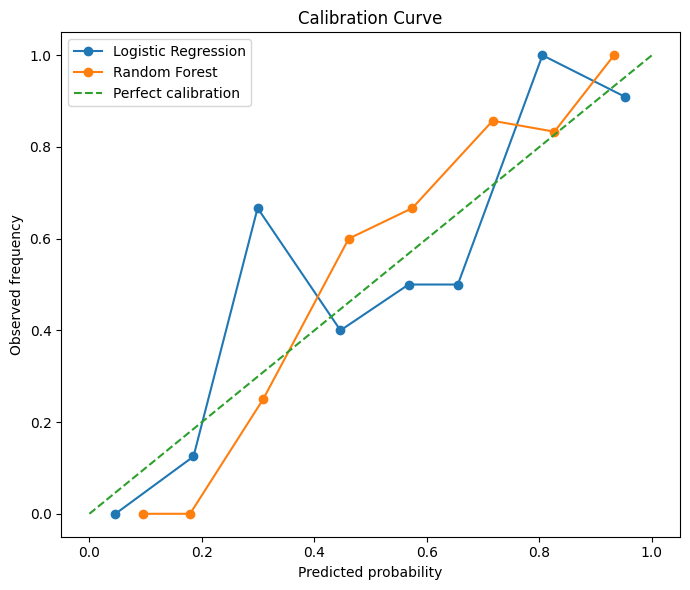

In [11]:

plt.figure(figsize=(7, 6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8)
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig("figures/calibration_curve.png", dpi=200)
plt.show()

In [12]:
best_model_name = results_df.sort_values("roc_auc", ascending=False).iloc[0]["model"]
best_model = models[best_model_name]

probs = best_model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

analysis_df = X_test.copy()
analysis_df["true"] = y_test.values
analysis_df["pred"] = preds
analysis_df["prob_disease"] = probs
analysis_df["confidence"] = np.maximum(probs, 1 - probs)
analysis_df["correct"] = analysis_df["true"] == analysis_df["pred"]

high_conf_errors = analysis_df[
    (analysis_df["correct"] == False) &
    (analysis_df["confidence"] >= 0.80)
].sort_values("confidence", ascending=False)

high_conf_errors.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,true,pred,prob_disease,confidence,correct
252,64,1,4,128,263,0,0,105,1,0.2,2,1.0,7.0,0,1,0.953305,0.953305,False
183,59,1,1,178,270,0,2,145,0,4.2,3,0.0,7.0,0,1,0.930838,0.930838,False


In [17]:
## confidence histogram plotted here

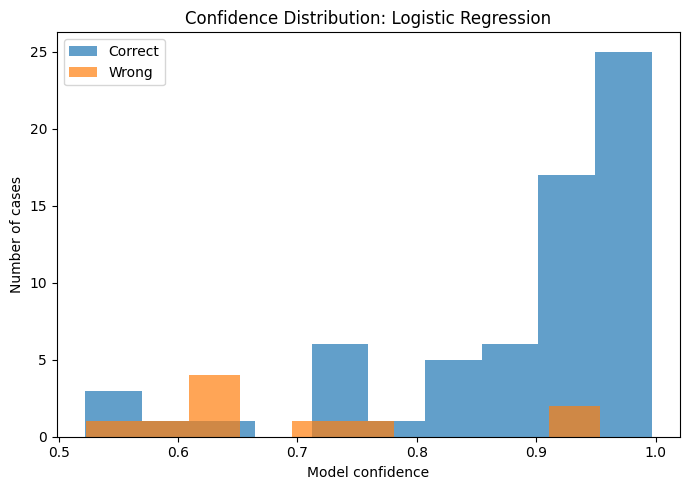

In [14]:
plt.figure(figsize=(7, 5))

plt.hist(
    analysis_df[analysis_df["correct"]]["confidence"],
    alpha=0.7,
    label="Correct",
    bins=10
)

plt.hist(
    analysis_df[~analysis_df["correct"]]["confidence"],
    alpha=0.7,
    label="Wrong",
    bins=10
)

plt.xlabel("Model confidence")
plt.ylabel("Number of cases")
plt.title(f"Confidence Distribution: {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig("figures/confidence_errors.png", dpi=200)
plt.show()

In [15]:
## Human heuristic baseline

In [18]:
def clinician_heuristic(row):
    score = 0
    
    if row["age"] >= 55:
        score += 1
    if row["trestbps"] >= 140:
        score += 1
    if row["chol"] >= 240:
        score += 1
    if row["thalach"] < 140:
        score += 1
    if row["exang"] == 1:
        score += 1
    if row["oldpeak"] >= 2:
        score += 1
    if row["cp"] == 4:
        score += 1
    
    return 1 if score >= 3 else 0

heuristic_preds = X_test.apply(clinician_heuristic, axis=1)

heuristic_results = {
    "model": "Human-style heuristic",
    "accuracy": accuracy_score(y_test, heuristic_preds),
    "precision": precision_score(y_test, heuristic_preds),
    "recall": recall_score(y_test, heuristic_preds),
    "f1": f1_score(y_test, heuristic_preds)
}

heuristic_results

{'model': 'Human-style heuristic',
 'accuracy': 0.7466666666666667,
 'precision': 0.7222222222222222,
 'recall': 0.7428571428571429,
 'f1': 0.7323943661971831}

In [19]:
## disagreament values 

In [20]:
disagreement_df = analysis_df.copy()
disagreement_df["heuristic_pred"] = heuristic_preds.values
disagreement_df["ml_vs_heuristic_disagree"] = disagreement_df["pred"] != disagreement_df["heuristic_pred"]

disagreement_cases = disagreement_df[
    disagreement_df["ml_vs_heuristic_disagree"]
].sort_values("confidence", ascending=False)

disagreement_cases.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,true,pred,prob_disease,confidence,correct,heuristic_pred,ml_vs_heuristic_disagree
21,58,0,1,150,283,1,2,162,0,1.0,1,0.0,3.0,0,0,0.017005,0.982995,True,1,True
104,49,1,3,120,188,0,0,139,0,2.0,2,3.0,7.0,1,1,0.961459,0.961459,True,0,True
103,71,0,3,110,265,1,2,130,0,0.0,1,1.0,3.0,0,0,0.056269,0.943731,True,1,True
23,58,1,3,132,224,0,2,173,0,3.2,1,2.0,7.0,1,1,0.930126,0.930126,True,0,True
70,65,0,3,155,269,0,0,148,0,0.8,1,0.0,3.0,0,0,0.085570,0.914430,True,1,True
64,54,1,4,120,188,0,0,113,0,1.4,2,1.0,7.0,1,1,0.857280,0.857280,True,0,True
163,58,0,4,100,248,0,2,122,0,1.0,2,0.0,3.0,0,0,0.152404,0.847596,True,1,True
27,66,0,1,150,226,0,0,114,0,2.6,3,0.0,3.0,0,0,0.175073,0.824927,True,1,True
232,49,1,3,118,149,0,2,126,0,0.8,1,3.0,3.0,1,1,0.796055,0.796055,True,0,True
290,67,1,3,152,212,0,2,150,0,0.8,2,0.0,7.0,1,1,0.755997,0.755997,True,0,True


In [21]:
# confusion matrix

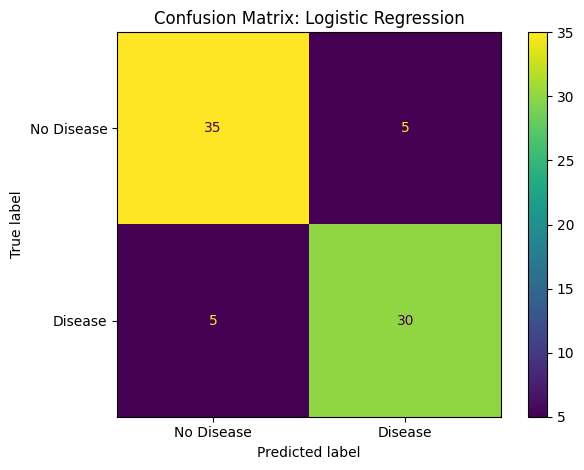

In [23]:
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
disp.plot()
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=200)
plt.show()